# 2025 Colorado State University Hackathon Starter Notebook

This notebook will offer an example for loading geospatial data into a potentially desirable format that can be used for completing the challenges.

_________________________________

In [3]:
!pip install rasterio

In [4]:
!pip install scikit-learn


In [5]:
import rasterio
import matplotlib.pyplot as plt 
import numpy as np

In [6]:
hillshade_path = "South_Clear_Creek/South_Clear_Creek/Lidar_DEM_Hillshade/South_Clear_Creek_BareEarth_Hillshade_1m.tif"
with rasterio.open(hillshade_path) as hillshade_dataset:
    # Read in the .tif file as a numpy array
    hillshade = hillshade_dataset.read()
    
    ### Special properties of the .tif file ###
    
    # Bands are similar to channels in an image, depending on the sensor data 
    # from a satellite there could be many different spectral bands
    print(f'Number of bands in the tiff file: {hillshade_dataset.count}') 
    
    # This is geospatial data so we use a coordinate reference system 
    # to map the data to its location on earth
    print(f'Coordinate Reference System: {hillshade_dataset.crs}')
    
    # From the georeference point set from the crs, we can see the size of
    # the earth that our sample covers in meters
    print(f'Bounds of our sample: {hillshade_dataset.bounds}')
    
# We now have a numpy array that we can manipulate
print(f'Format of sample: {type(hillshade)}')
print(f'Size of sample array: {hillshade.shape}')

Number of bands in the tiff file: 1
Coordinate Reference System: COMPD_CS["NAD83(2011) / UTM zone 13N + NAVD88 height",PROJCS["NAD83(2011) / UTM zone 13N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6342"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5703"]]]
Bounds of our sample: Boundin

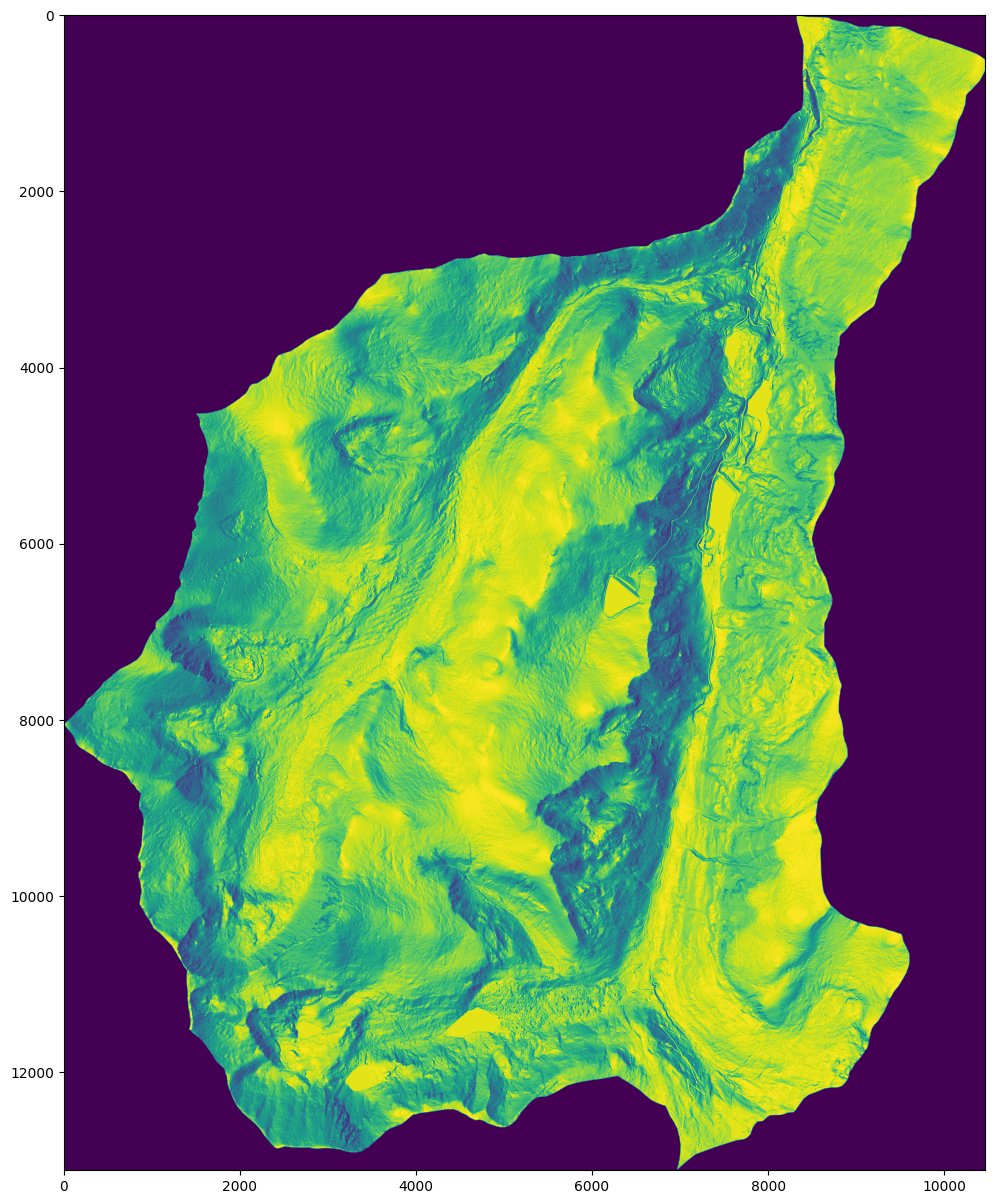

In [7]:
# View an image of the entire array
plt.figure(figsize=(15, 15))
plt.imshow(hillshade.transpose(1, 2, 0))
plt.show()

In [8]:
dem_path = "South_Clear_Creek/South_Clear_Creek/Lidar_DEM_Hillshade/South_Clear_Creek_BareEarth_DEM_1m.tif"
with rasterio.open(dem_path) as dem_dataset:
    # Read in the .tif file as a numpy array
    DEM = dem_dataset.read()
    
    ### Special properties of the .tif file ###
    
    # Bands are similar to channels in an image, depending on the sensor data 
    # from a satellite there could be many different spectral bands
    print(f'Number of bands in the tiff file: {dem_dataset.count}') 
    
    # This is geospatial data so we use a coordinate reference system 
    # to map the data to its location on earth
    print(f'Coordinate Reference System: {dem_dataset.crs}')
    
    # From the georeference point set from the crs, we can see the size of
    # the earth that our sample covers in meters
    print(f'Bounds of our sample: {dem_dataset.bounds}')
    
# We now have a numpy array that we can manipulate
print(f'Format of sample: {type(dem_dataset)}')
print(f'Size of sample array: {dem_dataset.shape}')

Number of bands in the tiff file: 1
Coordinate Reference System: COMPD_CS["NAD83(2011) / UTM zone 13N + NAVD88 height",PROJCS["NAD83(2011) / UTM zone 13N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6342"]],VERT_CS["NAVD88 height",VERT_DATUM["North American Vertical Datum 1988",2005,AUTHORITY["EPSG","5103"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5703"]]]
Bounds of our sample: Boundin

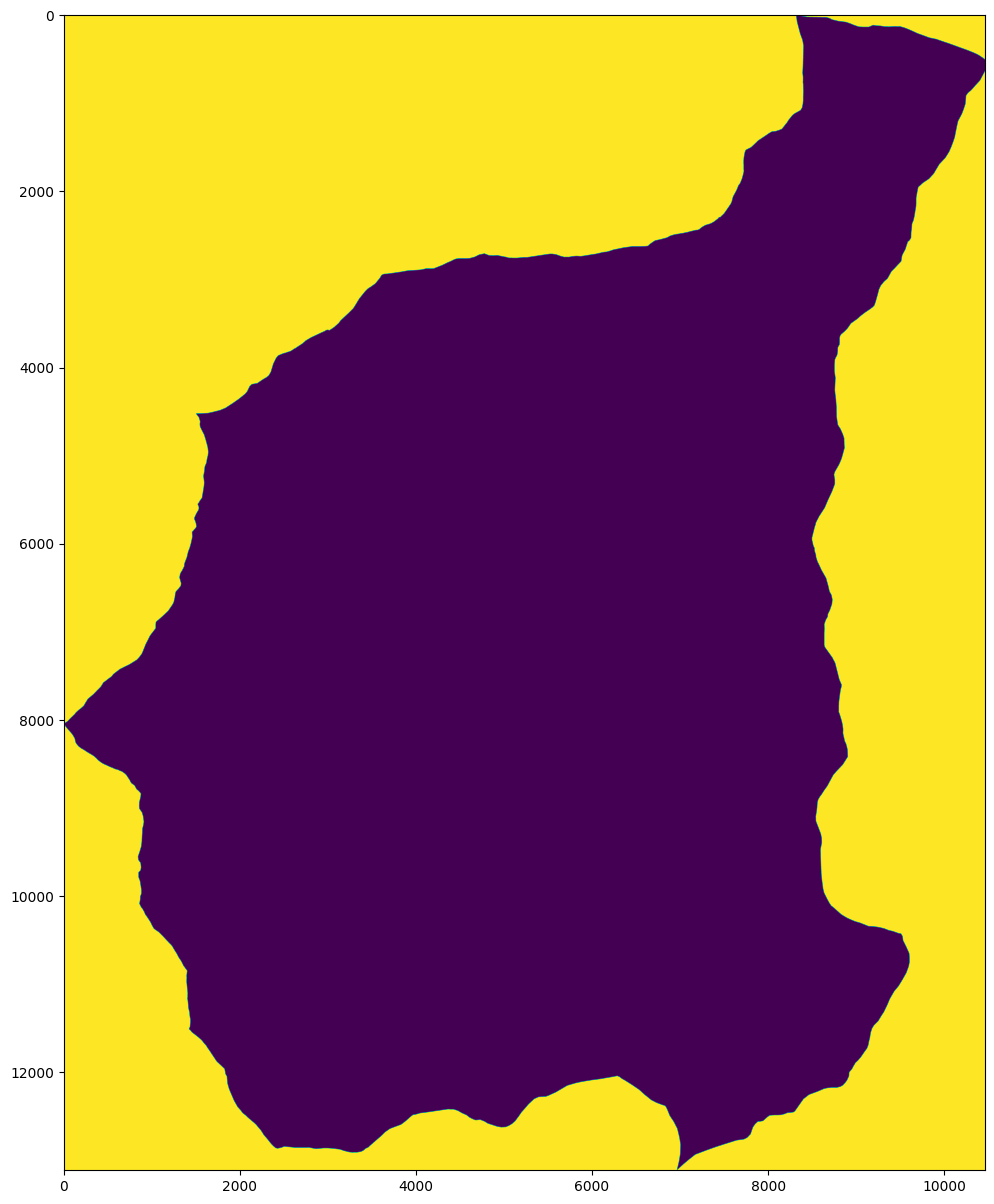

In [9]:
plt.figure(figsize=(15, 15))
plt.imshow(DEM.transpose(1, 2, 0))
plt.show()

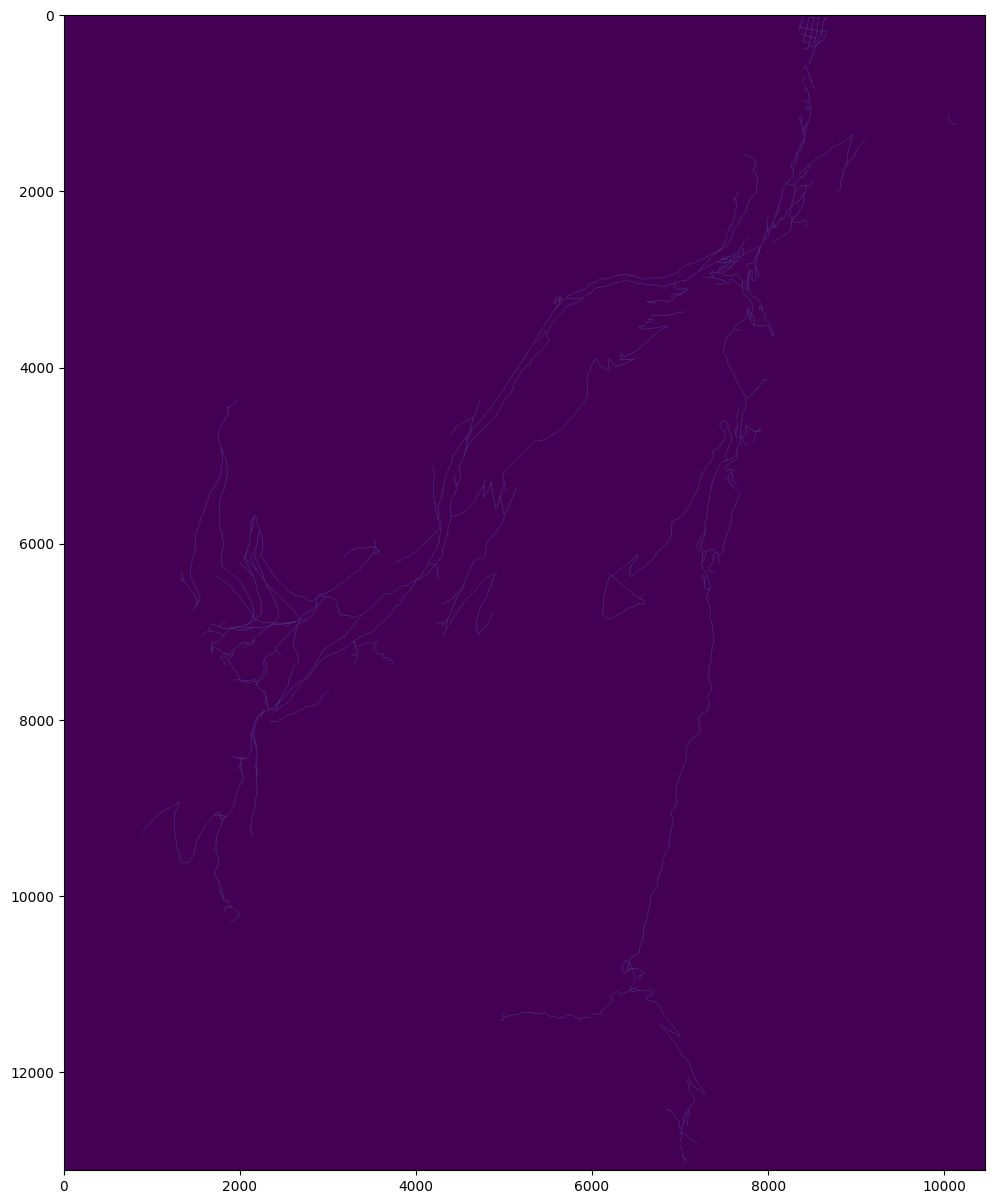

In [10]:
# Follow the same process to load the roads
roads_path = "South_Clear_Creek/South_Clear_Creek/Roads_Boundary/South_Clear_Creek_Roads_Mask.tif"
with rasterio.open(roads_path) as roads_dataset:
    roads_mask = roads_dataset.read()
plt.figure(figsize=(15,15))
plt.imshow(roads_mask.transpose(1, 2, 0))
plt.show()

In [11]:
road_matrix = roads_mask[0]  # shape: (H, W)
patch_size = 256

all_patches = []

rows, cols = road_matrix.shape
for i in range(0, rows, patch_size):
    for j in range(0, cols, patch_size):
        patch = road_matrix[i:i+patch_size, j:j+patch_size]

        # Skip partial patches at image edges (optional)
        if patch.shape != (patch_size, patch_size):
            continue

        # Determine if this patch contains any roads
        contains_road = int(np.any(patch == 1))  # 1 = road present, 0 = no road

        all_patches.append({
            'row_start': i,
            'col_start': j,
            'patch': patch,
            'label': contains_road
        })

In [12]:
Y = np.array([patch['patch'] for patch in all_patches])
Y = Y[..., np.newaxis]  

In [13]:
np.save("road_mask_patches.npy", Y)

import pickle
with open("road_patch_metadata.pkl", "wb") as f:
    pickle.dump(all_patches, f)

labels = np.array([patch['label'] for patch in all_patches])
np.save("road_patch_labels.npy", labels)

In [14]:
Y = np.load("road_mask_patches.npy")

with open("road_patch_metadata.pkl", "rb") as f:
    all_patches = pickle.load(f)

labels = np.load("road_patch_labels.npy")

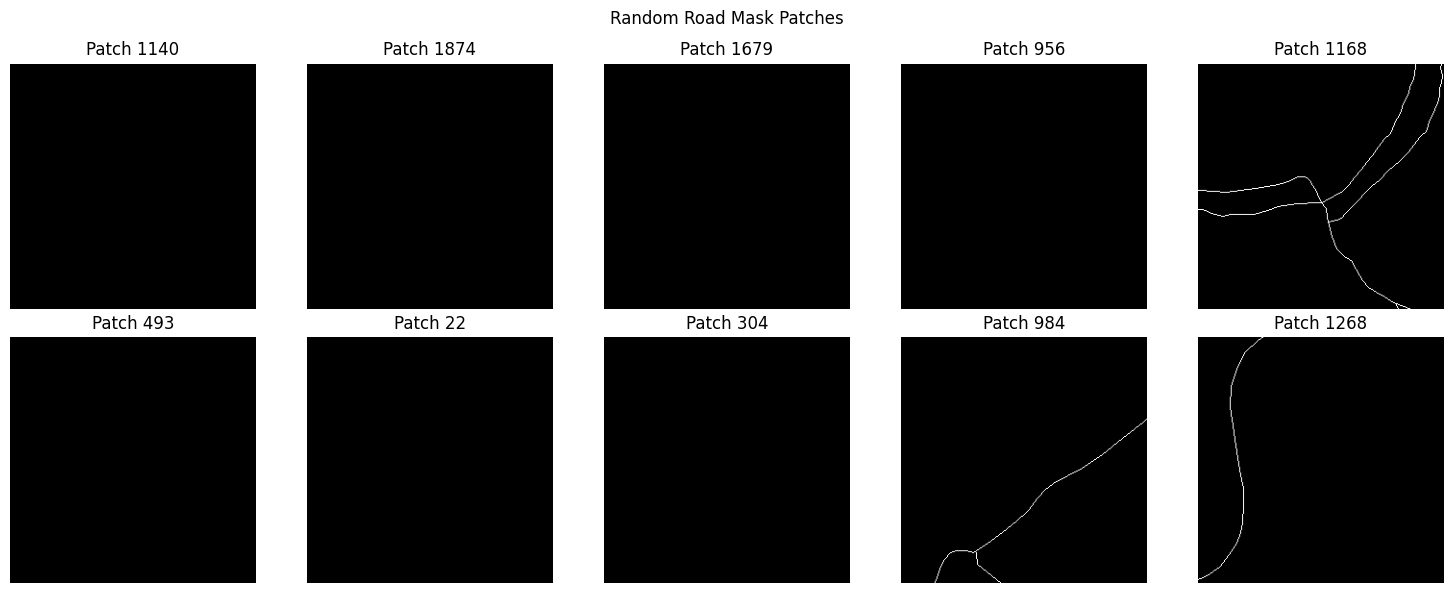

In [15]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax in axes.flat:
    idx = random.randint(0, len(Y)-1)
    ax.imshow(Y[idx, :, :, 0], cmap='gray')
    ax.set_title(f"Patch {idx}")
    ax.axis("off")
plt.suptitle("Random Road Mask Patches")
plt.tight_layout()
plt.show()


In [16]:
X_dem = []
X_hillshade = []

for patch in all_patches:
    i, j = patch['row_start'], patch['col_start']
    
    dem_patch = DEM[0, i:i+patch_size, j:j+patch_size]
    hill_patch = hillshade[0, i:i+patch_size, j:j+patch_size]
    
    if dem_patch.shape != (patch_size, patch_size) or hill_patch.shape != (patch_size, patch_size):
        continue
    
    X_dem.append(dem_patch)
    X_hillshade.append(hill_patch)

X_dem = np.array(X_dem)[..., np.newaxis]
X_hillshade = np.array(X_hillshade)[..., np.newaxis]

np.save("dem_patches.npy", X_dem)
np.save("hillshade_patches.npy", X_hillshade)

In [17]:
X_dem = X_dem.astype(np.float32)
X_hillshade = X_hillshade.astype(np.float32)

X_dem = (X_dem - X_dem.min()) / (X_dem.max() - X_dem.min())
X_hillshade = (X_hillshade - X_hillshade.min()) / (X_hillshade.max() - X_hillshade.min())


In [18]:
X_combined = np.concatenate([X_dem, X_hillshade], axis=-1)
np.save("X_combined.npy", X_combined)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_combined, Y, test_size=0.2, random_state=42)


In [20]:
# Separate patches by class
road_indices = [i for i, p in enumerate(all_patches) if p['label'] == 1]
no_road_indices = [i for i, p in enumerate(all_patches) if p['label'] == 0]

# Oversample roads: repeat road indices to match the number of no-road patches
n_no_road = len(no_road_indices)
n_road = len(road_indices)

if n_road < n_no_road:
    oversampled_road_indices = np.random.choice(road_indices, size=n_no_road, replace=True)
else:
    oversampled_road_indices = road_indices

# Combine and shuffle
balanced_indices = np.concatenate([no_road_indices, oversampled_road_indices])
np.random.shuffle(balanced_indices)

# Apply to your data
X_balanced = X_combined[balanced_indices]
Y_balanced = Y[balanced_indices]

In [21]:
!pip install torch torchvision torchaudio

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)


In [ ]:
from torch.utils.data import Dataset

class RoadDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)  # NCHW
        self.Y = torch.tensor(Y, dtype=torch.float32).permute(0, 3, 1, 2)  # NCHW

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


: 

In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim

device = "cpu"

model = UNet(in_channels=2, out_channels=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_dataset = RoadDataset(X_balanced, Y_balanced)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=False)

for epoch in range(10):  # Adjust epochs as needed
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    sample_input = torch.tensor(X_test[:1], dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    output = model(sample_input)
    pred = torch.sigmoid(output).cpu().numpy()[0, 0]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(X_test[0, :, :, 0]); plt.title("DEM")
plt.subplot(1,3,2); plt.imshow(X_test[0, :, :, 1]); plt.title("Hillshade")
plt.subplot(1,3,3); plt.imshow(pred > 0.5, cmap='gray'); plt.title("Predicted Road Mask")
plt.show()
